## EXAMEN DATA SCIENCE 2
naam:  \
klas:  204A  \
\
Voor je de file oplaadt, zorg ervoor dat alle cellen uitgevoerd zijn, zodat jouw resultaat ook weergegeven wordt!

### 0. Zet hier je imports

In [44]:
# imports
# Basis
import numpy as np
import pandas as pd
import math

# Visualisatie
import matplotlib.pyplot as plt
import seaborn as sns

# Voorbewerking / schaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures

# Data splitsing en validatie
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    validation_curve,
    GridSearchCV
)

# Regressie
from sklearn.linear_model import LinearRegression

# Classificatie
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Clustering
from sklearn.cluster import KMeans

# Evaluatie
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
    mean_absolute_percentage_error,
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

# Pipelines
from sklearn.pipeline import make_pipeline, Pipeline

# Datasets
from sklearn.datasets import load_wine

# Neural Networks (Keras / TensorFlow)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

# Metaheuristics (Simulated Annealing)
from simanneal import Annealer

### 1. Indexing

In [45]:
# a) 2

In [46]:
# b) df.iloc([3,3],[4,3]

### 2. Laad de 'Cars.csv' file

In [47]:
df = pd.read_csv('Cars.csv', sep=";", decimal=".")
df.head()

,Manufacturer,Type,Min.Price,Price,Max.Price,MPG.city,MPG.highway,AirBags,DriveTrain,Cylinders,...,Passengers,Length,Wheelbase,Width,Turn.circle,Rear.seat.room,Luggage.room,Weight,Origin,Model
0,Acura,Small,12.9,15.9,18.8,25,31,No airbag,Front,4,...,5,177,102,68,37,26.5,11.0,2705,non-USA,Acura Integra
1,Acura,Midsize,29.2,33.9,38.7,18,25,Driver & Passenger,Front,6,...,5,195,115,71,38,30.0,15.0,3560,non-USA,Acura Legend
2,Audi,Compact,25.9,29.1,32.3,20,26,Driver only,Front,6,...,5,180,102,67,37,28.0,14.0,3375,non-USA,Audi 90
3,Audi,Midsize,30.8,37.7,44.6,19,26,Driver & Passenger,Front,6,...,6,193,106,70,37,31.0,17.0,3405,non-USA,Audi 100
4,BMW,Midsize,23.7,30.0,36.2,22,30,Driver only,Rear,4,...,4,186,109,69,39,27.0,13.0,3640,non-USA,BMW 535i


### 3. Data Preparatie/Exploratie

In [48]:
# a
df.dropna(inplace=True)

In [49]:
# b
df["Model"] = df["Model"].str.split(" ").str.get(1).astype("string")
df.head()

,Manufacturer,Type,Min.Price,Price,Max.Price,MPG.city,MPG.highway,AirBags,DriveTrain,Cylinders,...,Passengers,Length,Wheelbase,Width,Turn.circle,Rear.seat.room,Luggage.room,Weight,Origin,Model
0,Acura,Small,12.9,15.9,18.8,25,31,No airbag,Front,4,...,5,177,102,68,37,26.5,11.0,2705,non-USA,Integra
1,Acura,Midsize,29.2,33.9,38.7,18,25,Driver & Passenger,Front,6,...,5,195,115,71,38,30.0,15.0,3560,non-USA,Legend
2,Audi,Compact,25.9,29.1,32.3,20,26,Driver only,Front,6,...,5,180,102,67,37,28.0,14.0,3375,non-USA,90
3,Audi,Midsize,30.8,37.7,44.6,19,26,Driver & Passenger,Front,6,...,6,193,106,70,37,31.0,17.0,3405,non-USA,100
4,BMW,Midsize,23.7,30.0,36.2,22,30,Driver only,Rear,4,...,4,186,109,69,39,27.0,13.0,3640,non-USA,535i


In [60]:
# c
df.groupby('Type')['Price'].mean()

Type
Compact    18.212500
Large      24.300000
Midsize    27.218182
Small      10.166667
Sporty     17.363636
Name: Price, dtype: float64

Text(0.5, 1.0, 'verband prijs - pk')

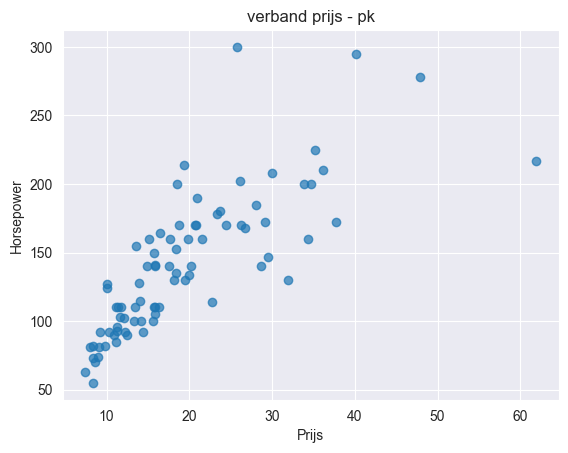

In [65]:
# d
plt.scatter(df['Price'], df['Horsepower'], alpha=0.7)
plt.xlabel("Prijs")
plt.ylabel("Horsepower")
plt.title("verband prijs - pk")

### 4. Neurale netwerken regressie

#### a. Train en test dataset voor predictors en target feature

In [52]:
y = df['Price']
X = df[['Cylinders','Horsepower','Passengers','Length']]
print(X.shape,y.shape)

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.06, random_state=42)

(81, 4) (81,)


#### b. definieer het model

In [53]:
inputs = Input(shape=(4,))

x = Dense(128, activation='relu')(inputs)
x = Dense(64, activation='relu')(x)

outputs = Dense(1, activation='linear')(x)

model = Model(inputs, outputs, name='Price')
model.summary()


model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['r2_score']
)

Model: "Price"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,961 (35.00 KB)

 Trainable params: 8,961 (35.00 KB)

 Non-trainable params: 0 (0.00 B)

#### c. train het model

In [54]:
history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 97.2212 - r2_score: 0.1732 - val_loss: 6.1736 - val_r2_score: 0.6344
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 64.7905 - r2_score: 0.4388 - val_loss: 21.5146 - val_r2_score: -0.2741
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 48.8250 - r2_score: 0.5411 - val_loss: 39.0091 - val_r2_score: -1.3101
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 51.3779 - r2_score: 0.5709 - val_loss: 23.2835 - val_r2_score: -0.3789
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 46.4419 - r2_score: 0.6053 - val_loss: 26.7770 - val_r2_score: -0.5857
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 50.7518 - r2_score: 0.5804 - val_loss: 35.7983 - val_r2_score: -1.1200
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 43.5163 - r2_score: 0.6263 - val_loss: 47.8352 - val_r2_score: -1.8328
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 42.3216 - r2_score: 0.6601 - val_loss: 44.4345 - 

#### d. Maak een voorspelling

In [55]:
new_car = pd.DataFrame({'Cylinders':[4], 'Horsepower':[200], 'Passengers': [4], 'Length':[190]})
predictions = model.predict(new_car)
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
[[27.905178]]


### 5. Random forest grid search

#### a. Dataset voor predictors en target feature

In [56]:
y = df['Type']
X = df[['Price','Cylinders','Horsepower','Passengers','Length']]

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42)

#### b. Grid search

In [57]:
model = RandomForestClassifier(random_state=42)
grid_param = {'n_estimators': np.arange(12, 18),
              'max_depth': np.arange(3, 6)}
grid = GridSearchCV(model, param_grid=grid_param, cv=4)
grid.fit(x_train, y_train)

model = grid.best_estimator_
print(grid.best_params_)
y_test_pred = model.predict(x_test)
acc = accuracy_score(y_true=y_test, y_pred=y_test_pred)
print(acc)


{'max_depth': 4, 'n_estimators': 16}
0.6666666666666666


#### c. Scores voor de test dataset

In [58]:
prec = precision_score(y_true=y_test, y_pred=y_test_pred, average='weighted')
rec = recall_score(y_true=y_test, y_pred=y_test_pred, average='weighted')
f1 = f1_score(y_true=y_test, y_pred=y_test_pred, average='weighted')

print(f'PREC : {prec:.3f} - REC : {rec:.3f} - F1 : {f1:.3f}')

PREC : 0.778 - REC : 0.667 - F1 : 0.714


### 6. Simulated annealing

#### a. Optimale fiets

In [93]:
A_kwal = np.array([9, 8, 9, 9, 9, 8, 9, 9, 8, 9])
B_kwal = np.array([7, 6, 7, 8, 6, 6, 8, 8, 7, 6]) 
A_prijs = np.array([300, 250, 350, 200, 300, 320, 150, 250, 450, 160])
B_prijs = np.array([200, 100, 300, 150, 250, 220,  50, 180, 350,  20]) 

class BikeProblem(Annealer):
    def energy(self):
        B_onderdelen = self.state               # In de B_onderdelen array zijn alle geselecteerde B-onderdelen gelijk aan 1
        A_onderdelen = - (B_onderdelen - 1)     # In de A_onderdelen array zijn alle geselecteerde A-onderdelen gelijk aan 1
        total_price = ((B_onderdelen * B_prijs) + (A_onderdelen * A_prijs)).sum()
        if total_price > 2500:
            total_price = 0
        else:
            total_price = ((B_onderdelen * B_prijs) + (A_onderdelen * A_prijs)).sum()
        return -total_price

    def move(self):
        i = np.random.randint(0,2)
        self.state[i] = np.random.randint(0,len(self.state))
        self.state[i] = not self.state[i]

init_sol = np.random.randint(0,2,size=len(A_prijs))
bike = BikeProblem(init_sol)
bike.anneal()

 Temperature        Energy    Accept   Improve     Elapsed   Remaining


(array([0, 1, 0, 0, 0, 0, 1, 0, 0, 0]), -2480)

#### b. Prijs optimale fiets

In [ ]:
2480